# Hospital Readmission Prediction - Modeling Notebook

This notebook trains and compares standard classification models for predicting 30-day readmission in the UCI Diabetes 130-US Hospitals dataset.

The preprocessing follows `preprocessing_decision_log.md`, which is the source of truth for this project stage. The test set is kept untouched until models are selected from validation results.

**Final reproducibility note:** the first training section uses the conservative first-encounter row scope required for the original notebook. The current final headline result is produced by `FINAL_MODEL_PIPELINE.py`, which uses the later patient-safe all-encounter CatBoost pipeline with prior patient-history features and reaches PR-AUC 0.2414 on the held-out test split. The extended sections below summarize the saved experiment audit trail that led to that final pipeline.


## Modeling Plan

1. Load the raw dataset from `archive/diabetic_data.csv`.
2. Apply the accepted row scope: first encounter per patient, excluding hospice/expired discharges.
3. Create the binary target `readmitted_30`.
4. Apply accepted preprocessing decisions, including diagnosis groups, administrative code groups, age groups, medication summaries, service utilization, rare-category handling, one-hot encoding, and model-specific scaling.
5. Split into stratified train/validation/test sets using a 70/15/15 split.
6. Compare several standard classifiers on validation data.
7. Select final models using validation results only, then evaluate those selected models on the untouched test set.
8. Display the extended experiment audit trail and point to `FINAL_MODEL_PIPELINE.py` as the canonical final model run.


In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
RARE_CATEGORY_MIN_COUNT = 200
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)


## Load Data

The raw UCI file uses `?` for several missing values. These are loaded as missing values with `keep_default_na=False`, while strings such as `None` in `A1Cresult` and `max_glu_serum` remain real categories because they mean the lab test was not performed.


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "archive" / "diabetic_data.csv"

raw = pd.read_csv(DATA_PATH, na_values="?", keep_default_na=False)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
display(raw.head())


Raw shape: 101,766 rows x 50 columns


/var/folders/c4/xyqh0fz572l295kbclh29k700000gp/T/ipykernel_90274/3574516576.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(DATA_PATH, na_values="?", keep_default_na=False)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Accepted Row Scope and Target

Decision 1 keeps one row per patient by sorting by `encounter_id` and taking each patient's first observed encounter. Encounters ending in hospice or death are removed. Decision 2 defines the positive class as readmission within 30 days.


In [3]:
HOSPICE_OR_EXPIRED_DISCHARGE_IDS = [11, 13, 14, 19, 20, 21]

model_df = raw.copy()
model_df["readmitted_30"] = model_df["readmitted"].eq("<30").astype(int)

first_encounter_df = (
    model_df.sort_values("encounter_id")
    .drop_duplicates("patient_nbr", keep="first")
    .copy()
)

model_scope_df = first_encounter_df[
    ~first_encounter_df["discharge_disposition_id"].isin(HOSPICE_OR_EXPIRED_DISCHARGE_IDS)
].copy()

scope_summary = pd.DataFrame(
    [
        {
            "dataset": "All encounters",
            "rows": len(model_df),
            "unique_patients": model_df["patient_nbr"].nunique(),
            "positive_rate": model_df["readmitted_30"].mean(),
        },
        {
            "dataset": "First encounter per patient",
            "rows": len(first_encounter_df),
            "unique_patients": first_encounter_df["patient_nbr"].nunique(),
            "positive_rate": first_encounter_df["readmitted_30"].mean(),
        },
        {
            "dataset": "First encounter, excluding hospice/expired",
            "rows": len(model_scope_df),
            "unique_patients": model_scope_df["patient_nbr"].nunique(),
            "positive_rate": model_scope_df["readmitted_30"].mean(),
        },
    ]
)
scope_summary["positive_rate_pct"] = scope_summary["positive_rate"] * 100
display(scope_summary.drop(columns="positive_rate"))

target_counts = model_scope_df["readmitted_30"].value_counts().sort_index()
print("Target counts after accepted row scope:")
print(target_counts.to_string())
print(f"Positive rate: {model_scope_df['readmitted_30'].mean() * 100:.2f}%")


,dataset,rows,unique_patients,positive_rate_pct
0,All encounters,101766,71518,11.159916
1,First encounter per patient,71518,71518,8.799183
2,"First encounter, excluding hospice/expired",69973,69973,8.970603


Target counts after accepted row scope:
readmitted_30
0    63696
1     6277
Positive rate: 8.97%


## Preprocessing Helpers

These helpers implement the accepted preprocessing decisions from the decision log. The only learned preprocessing rule is rare-category grouping for `medical_specialty` and `payer_code`; it is fitted on the training split only inside each sklearn pipeline.


In [4]:
MEDICATION_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]

RARE_OR_ZERO_VARIANCE_MEDICATION_COLS = [
    "chlorpropamide",
    "acetohexamide",
    "tolbutamide",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

ID_AND_TARGET_COLUMNS = ["readmitted", "readmitted_30", "encounter_id", "patient_nbr"]


def icd9_group(code):
    # Paper-style broad ICD-9 grouping used in the EDA and decision log.
    if pd.isna(code):
        return "Missing"
    text = str(code).strip()
    if text == "":
        return "Missing"
    if text.startswith("V") or text.startswith("E"):
        return "External/Supplemental"
    try:
        value = float(text)
    except ValueError:
        return "Other"

    whole = int(value)
    if 390 <= value <= 459 or whole == 785:
        return "Circulatory"
    if 460 <= value <= 519 or whole == 786:
        return "Respiratory"
    if 520 <= value <= 579 or whole == 787:
        return "Digestive"
    if 250 <= value < 251:
        return "Diabetes"
    if 800 <= value <= 999:
        return "Injury/Poisoning"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if 580 <= value <= 629 or whole == 788:
        return "Genitourinary"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"


def group_admission_type(x):
    if x in [1, 2, 7]:
        return "Emergency/Urgent/Trauma"
    if x == 3:
        return "Elective"
    if x in [5, 6, 8]:
        return "Unknown/Not available"
    return "Other/Newborn"


def group_discharge_disposition(x):
    if x == 1:
        return "Home"
    return "Other"


def group_admission_source(x):
    if x == 7:
        return "Emergency room"
    if x in [1, 2, 3]:
        return "Physician/clinic referral"
    return "Other"


def group_age_paper(age_value):
    if age_value in ["[0-10)", "[10-20)", "[20-30)"]:
        return "<=30"
    if age_value in ["[30-40)", "[40-50)", "[50-60)"]:
        return "30-60"
    return ">60"


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    # Map infrequent training categories and unseen categories to Other.

    def __init__(self, columns=None, min_count=200, missing_label="Missing", other_label="Other"):
        self.columns = columns
        self.min_count = min_count
        self.missing_label = missing_label
        self.other_label = other_label

    def fit(self, X, y=None):
        X = X.copy()
        self.frequent_categories_ = {}
        for col in self.columns:
            values = X[col].fillna(self.missing_label).astype(str)
            counts = values.value_counts(dropna=False)
            keep = set(counts[counts >= self.min_count].index)
            keep.add(self.missing_label)
            self.frequent_categories_[col] = keep
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            values = X[col].fillna(self.missing_label).astype(str)
            keep = self.frequent_categories_[col]
            X[col] = np.where(values.isin(keep), values, self.other_label)
        return X


In [5]:
def build_feature_matrix(scoped_df):
    y = scoped_df["readmitted_30"].astype(int).copy()
    X = scoped_df.drop(columns=ID_AND_TARGET_COLUMNS).copy()

    # Explicit missing categories from the decision log.
    X["race"] = X["race"].fillna("Missing").astype(str)
    X["medical_specialty"] = X["medical_specialty"].fillna("Missing").astype(str)
    X["payer_code"] = X["payer_code"].fillna("Missing").astype(str)

    for diag_col in ["diag_1", "diag_2", "diag_3"]:
        X[diag_col] = X[diag_col].fillna("Missing").astype(str)
        X[f"{diag_col}_group"] = X[diag_col].apply(icd9_group)

    # Paper-informed administrative groupings.
    X["admission_type_group"] = X["admission_type_id"].apply(group_admission_type)
    X["discharge_disposition_group"] = X["discharge_disposition_id"].apply(group_discharge_disposition)
    X["admission_source_group"] = X["admission_source_id"].apply(group_admission_source)

    # Paper age grouping and accepted demographic handling.
    X["age_group_paper"] = X["age"].apply(group_age_paper)

    # Medication summaries before dropping rare medication columns.
    X["num_diabetes_meds_used"] = X[MEDICATION_COLS].ne("No").sum(axis=1)
    X["num_diabetes_med_changes"] = X[MEDICATION_COLS].isin(["Up", "Down"]).sum(axis=1)

    # Prior utilization summary.
    X["service_utilization"] = (
        X["number_outpatient"] + X["number_emergency"] + X["number_inpatient"]
    )

    columns_to_drop = [
        "weight",
        "diag_1",
        "diag_2",
        "diag_3",
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id",
        "age",
        "gender",
    ] + RARE_OR_ZERO_VARIANCE_MEDICATION_COLS

    X = X.drop(columns=columns_to_drop, errors="ignore")

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns
    X[categorical_cols] = X[categorical_cols].fillna("Missing").astype(str)

    return X, y


X, y = build_feature_matrix(model_scope_df)
print(f"Feature matrix before encoding: {X.shape[0]:,} rows x {X.shape[1]:,} columns")
print(f"Target positive rate: {y.mean() * 100:.2f}%")
display(X.head())


Feature matrix before encoding: 69,973 rows x 36 columns
Target positive rate: 8.97%


,race,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,insulin,glyburide-metformin,change,diabetesMed,diag_1_group,diag_2_group,diag_3_group,admission_type_group,discharge_disposition_group,admission_source_group,age_group_paper,num_diabetes_meds_used,num_diabetes_med_changes,service_utilization
8,Caucasian,13,Missing,Missing,68,2,28,0,0,0,8,None,None,No,No,No,No,Steady,No,No,No,No,Steady,No,Ch,Yes,Circulatory,Circulatory,Other,Emergency/Urgent/Trauma,Home,Other,>60,2,0,0
9,Caucasian,12,Missing,InternalMedicine,33,3,18,0,0,0,8,None,None,No,No,No,No,No,No,No,Steady,No,Steady,No,Ch,Yes,Circulatory,Neoplasms,Respiratory,Elective,Other,Other,>60,2,0,0
4,Caucasian,1,Missing,Missing,51,0,8,0,0,0,5,None,None,No,No,No,No,Steady,No,No,No,No,Steady,No,Ch,Yes,Neoplasms,Neoplasms,Diabetes,Emergency/Urgent/Trauma,Home,Emergency room,30-60,2,0,0
10,AfricanAmerican,9,Missing,Missing,47,2,17,0,0,0,9,None,None,No,No,No,No,No,No,No,No,No,Steady,No,No,Yes,Diabetes,Circulatory,Injury/Poisoning,Emergency/Urgent/Trauma,Home,Emergency room,30-60,1,0,0
5,Caucasian,3,Missing,Missing,31,6,16,0,0,0,9,None,None,No,No,No,No,No,No,No,No,No,Steady,No,No,Yes,Circulatory,Circulatory,Diabetes,Emergency/Urgent/Trauma,Home,Physician/clinic referral,30-60,1,0,0


## Train / Validation / Test Split

The split is stratified and uses the accepted 70/15/15 proportions. Because the row scope already keeps one row per patient, a grouped split is not required.


In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

relative_val_size = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=relative_val_size,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(y_train), "positive": int(y_train.sum()), "positive_rate_pct": y_train.mean() * 100},
        {"split": "validation", "rows": len(y_val), "positive": int(y_val.sum()), "positive_rate_pct": y_val.mean() * 100},
        {"split": "test", "rows": len(y_test), "positive": int(y_test.sum()), "positive_rate_pct": y_test.mean() * 100},
    ]
)
display(split_summary)


,split,rows,positive,positive_rate_pct
0,train,48981,4394,8.970825
1,validation,10496,941,8.965320
2,test,10496,942,8.974848


## Model Preprocessing Pipelines

Categorical variables are one-hot encoded with unknown-category protection. Numeric features are scaled for Logistic Regression, Gaussian Naive Bayes, and KNN if KNN is run. Tree-based models use unscaled numeric features.


In [7]:
rare_category_cols = ["medical_specialty", "payer_code"]
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
print(categorical_cols)
print(f"Numeric columns: {len(numeric_cols)}")
print(numeric_cols)


def make_preprocessor(scale_numeric=False):
    numeric_step = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler() if scale_numeric else "passthrough"),
        ]
    )
    categorical_step = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_step, categorical_cols),
            ("numeric", numeric_step, numeric_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_pipeline(model, scale_numeric=False):
    return Pipeline(
        steps=[
            (
                "rare_categories",
                RareCategoryGrouper(
                    columns=rare_category_cols,
                    min_count=RARE_CATEGORY_MIN_COUNT,
                ),
            ),
            ("preprocess", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", model),
        ]
    )


Categorical columns: 25
['race', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'admission_type_group', 'discharge_disposition_group', 'admission_source_group', 'age_group_paper']
Numeric columns: 11
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'num_diabetes_meds_used', 'num_diabetes_med_changes', 'service_utilization']


## Models

The comparison includes a majority-class baseline and standard course-project classifiers. Class weights or balanced sample weights are used where supported. KNN is skipped automatically here because the training split has nearly 49,000 rows after one-hot encoding, which makes validation-time distance calculations expensive relative to the other models.


In [8]:
models_to_train = [
    {
        "name": "Logistic Regression",
        "pipeline": make_pipeline(
            LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            scale_numeric=True,
        ),
        "uses_sample_weight": False,
    },
    {
        "name": "Decision Tree",
        "pipeline": make_pipeline(
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=100,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "uses_sample_weight": False,
    },
    {
        "name": "Random Forest",
        "pipeline": make_pipeline(
            RandomForestClassifier(
                n_estimators=150,
                max_depth=14,
                min_samples_leaf=50,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "uses_sample_weight": False,
    },
    {
        "name": "Extra Trees",
        "pipeline": make_pipeline(
            ExtraTreesClassifier(
                n_estimators=150,
                max_depth=14,
                min_samples_leaf=50,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "uses_sample_weight": False,
    },
    {
        "name": "Gradient Boosting",
        "pipeline": make_pipeline(
            GradientBoostingClassifier(
                n_estimators=120,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "uses_sample_weight": True,
    },
    {
        "name": "HistGradientBoosting",
        "pipeline": make_pipeline(
            HistGradientBoostingClassifier(
                max_iter=180,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=0.1,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "uses_sample_weight": False,
    },
    {
        "name": "AdaBoost",
        "pipeline": make_pipeline(
            AdaBoostClassifier(
                n_estimators=120,
                learning_rate=0.05,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "uses_sample_weight": True,
    },
    {
        "name": "Gaussian Naive Bayes",
        "pipeline": make_pipeline(
            GaussianNB(),
            scale_numeric=True,
        ),
        "uses_sample_weight": True,
    },
]

KNN_ROW_LIMIT = 30_000
skipped_models = []
if len(X_train) <= KNN_ROW_LIMIT:
    models_to_train.append(
        {
            "name": "KNN",
            "pipeline": make_pipeline(
                KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1),
                scale_numeric=True,
            ),
            "uses_sample_weight": False,
        }
    )
else:
    skipped_models.append(
        {
            "model": "KNN",
            "reason": f"Skipped because train rows ({len(X_train):,}) exceed the runtime guardrail ({KNN_ROW_LIMIT:,}) for high-dimensional distance-based validation.",
        }
    )

display(pd.DataFrame([{"model": m["name"], "sample_weight_fit": m["uses_sample_weight"]} for m in models_to_train]))
if skipped_models:
    display(pd.DataFrame(skipped_models))


,model,sample_weight_fit
0,Logistic Regression,False
1,Decision Tree,False
2,Random Forest,False
3,Extra Trees,False
4,Gradient Boosting,True
5,HistGradientBoosting,False
6,AdaBoost,True
7,Gaussian Naive Bayes,True


,model,reason
0,KNN,"Skipped because train rows (48,981) exceed the..."


## Metric Helpers

PR-AUC and recall are emphasized because the positive class is rare. The confusion matrix is stored for every evaluated model.


In [9]:
def positive_scores(estimator, X_eval):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_eval)[:, 1]
    if hasattr(estimator, "decision_function"):
        raw_scores = estimator.decision_function(X_eval)
        return 1 / (1 + np.exp(-raw_scores))
    raise TypeError("Estimator does not expose predict_proba or decision_function.")


def metric_row(model_name, split_name, y_true, y_pred, y_score, fit_seconds=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        "model": model_name,
        "split": split_name,
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
        "fit_seconds": fit_seconds,
    }


def evaluate_estimator(model_name, estimator, X_eval, y_eval, split_name, fit_seconds=None):
    y_score = positive_scores(estimator, X_eval)
    y_pred = estimator.predict(X_eval)
    return metric_row(model_name, split_name, y_eval, y_pred, y_score, fit_seconds=fit_seconds)


def evaluate_majority_baseline(X_eval, y_eval, split_name):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(np.zeros((len(y_train), 1)), y_train)
    y_pred = dummy.predict(np.zeros((len(y_eval), 1)))
    y_score = np.full(len(y_eval), y_train.mean())
    return metric_row("Majority Baseline", split_name, y_eval, y_pred, y_score, fit_seconds=0.0)


## Validation Evaluation for All Models

Only validation data is used for model comparison and final model selection in this section.


In [10]:
sample_weight_balanced = compute_sample_weight(class_weight="balanced", y=y_train)

validation_rows = [evaluate_majority_baseline(X_val, y_val, "validation")]
fitted_models = {}

for spec in models_to_train:
    name = spec["name"]
    estimator = spec["pipeline"]
    start = time.perf_counter()
    if spec["uses_sample_weight"]:
        estimator.fit(X_train, y_train, model__sample_weight=sample_weight_balanced)
    else:
        estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    fitted_models[name] = estimator
    validation_rows.append(evaluate_estimator(name, estimator, X_val, y_val, "validation", fit_seconds=fit_seconds))
    print(f"Finished {name} in {fit_seconds:.1f} seconds")

validation_metrics = pd.DataFrame(validation_rows)
validation_metrics_display = validation_metrics.sort_values(["pr_auc", "recall"], ascending=False).reset_index(drop=True)
display(validation_metrics_display.round(4))


Finished Logistic Regression in 1.3 seconds


Finished Decision Tree in 0.6 seconds


Finished Random Forest in 1.1 seconds


Finished Extra Trees in 0.9 seconds


Finished Gradient Boosting in 14.5 seconds


Finished HistGradientBoosting in 3.3 seconds


Finished AdaBoost in 6.8 seconds


Finished Gaussian Naive Bayes in 0.3 seconds


,model,split,pr_auc,roc_auc,recall,precision,f1,accuracy,tn,fp,fn,tp,fit_seconds
0,Random Forest,validation,0.1517,0.6464,0.5600,0.1398,0.2237,0.6515,6311,3244,414,527,1.1276
1,HistGradientBoosting,validation,0.1512,0.6492,0.5972,0.1336,0.2183,0.6165,5909,3646,379,562,3.2504
2,Logistic Regression,validation,0.1482,0.6380,0.5824,0.1307,0.2135,0.6153,5910,3645,393,548,1.2537
3,Gradient Boosting,validation,0.1470,0.6388,0.5898,0.1320,0.2157,0.6155,5905,3650,386,555,14.4883
4,Extra Trees,validation,0.1431,0.6347,0.5600,0.1355,0.2182,0.6401,6192,3363,414,527,0.8735
5,Decision Tree,validation,0.1311,0.6165,0.5494,0.1278,0.2074,0.6236,6028,3527,424,517,0.5713
6,AdaBoost,validation,0.1229,0.6077,0.6153,0.1263,0.2096,0.5840,5551,4004,362,579,6.8038
7,Gaussian Naive Bayes,validation,0.1122,0.5817,0.9628,0.0904,0.1652,0.1279,436,9119,35,906,0.3236
8,Majority Baseline,validation,0.0897,0.5000,0.0000,0.0000,0.0000,0.9103,9555,0,941,0,0.0000


## Validation Comparison Tables

The first table is sorted by PR-AUC, with recall as a secondary sort. The second table highlights recall/F1 tradeoffs.


In [11]:
validation_by_pr_auc = validation_metrics.sort_values(["pr_auc", "recall"], ascending=False).reset_index(drop=True)
validation_by_recall = validation_metrics.sort_values(["recall", "pr_auc"], ascending=False).reset_index(drop=True)

metric_cols = ["model", "pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy", "tn", "fp", "fn", "tp", "fit_seconds"]

print("Validation metrics sorted by PR-AUC:")
display(validation_by_pr_auc[metric_cols].round(4))

print("Validation metrics sorted by recall:")
display(validation_by_recall[metric_cols].round(4))


Validation metrics sorted by PR-AUC:


,model,pr_auc,roc_auc,recall,precision,f1,accuracy,tn,fp,fn,tp,fit_seconds
0,Random Forest,0.1517,0.6464,0.5600,0.1398,0.2237,0.6515,6311,3244,414,527,1.1276
1,HistGradientBoosting,0.1512,0.6492,0.5972,0.1336,0.2183,0.6165,5909,3646,379,562,3.2504
2,Logistic Regression,0.1482,0.6380,0.5824,0.1307,0.2135,0.6153,5910,3645,393,548,1.2537
3,Gradient Boosting,0.1470,0.6388,0.5898,0.1320,0.2157,0.6155,5905,3650,386,555,14.4883
4,Extra Trees,0.1431,0.6347,0.5600,0.1355,0.2182,0.6401,6192,3363,414,527,0.8735
5,Decision Tree,0.1311,0.6165,0.5494,0.1278,0.2074,0.6236,6028,3527,424,517,0.5713
6,AdaBoost,0.1229,0.6077,0.6153,0.1263,0.2096,0.5840,5551,4004,362,579,6.8038
7,Gaussian Naive Bayes,0.1122,0.5817,0.9628,0.0904,0.1652,0.1279,436,9119,35,906,0.3236
8,Majority Baseline,0.0897,0.5000,0.0000,0.0000,0.0000,0.9103,9555,0,941,0,0.0000


Validation metrics sorted by recall:


,model,pr_auc,roc_auc,recall,precision,f1,accuracy,tn,fp,fn,tp,fit_seconds
0,Gaussian Naive Bayes,0.1122,0.5817,0.9628,0.0904,0.1652,0.1279,436,9119,35,906,0.3236
1,AdaBoost,0.1229,0.6077,0.6153,0.1263,0.2096,0.5840,5551,4004,362,579,6.8038
2,HistGradientBoosting,0.1512,0.6492,0.5972,0.1336,0.2183,0.6165,5909,3646,379,562,3.2504
3,Gradient Boosting,0.1470,0.6388,0.5898,0.1320,0.2157,0.6155,5905,3650,386,555,14.4883
4,Logistic Regression,0.1482,0.6380,0.5824,0.1307,0.2135,0.6153,5910,3645,393,548,1.2537
5,Random Forest,0.1517,0.6464,0.5600,0.1398,0.2237,0.6515,6311,3244,414,527,1.1276
6,Extra Trees,0.1431,0.6347,0.5600,0.1355,0.2182,0.6401,6192,3363,414,527,0.8735
7,Decision Tree,0.1311,0.6165,0.5494,0.1278,0.2074,0.6236,6028,3527,424,517,0.5713
8,Majority Baseline,0.0897,0.5000,0.0000,0.0000,0.0000,0.9103,9555,0,941,0,0.0000


## Validation Visual Comparisons


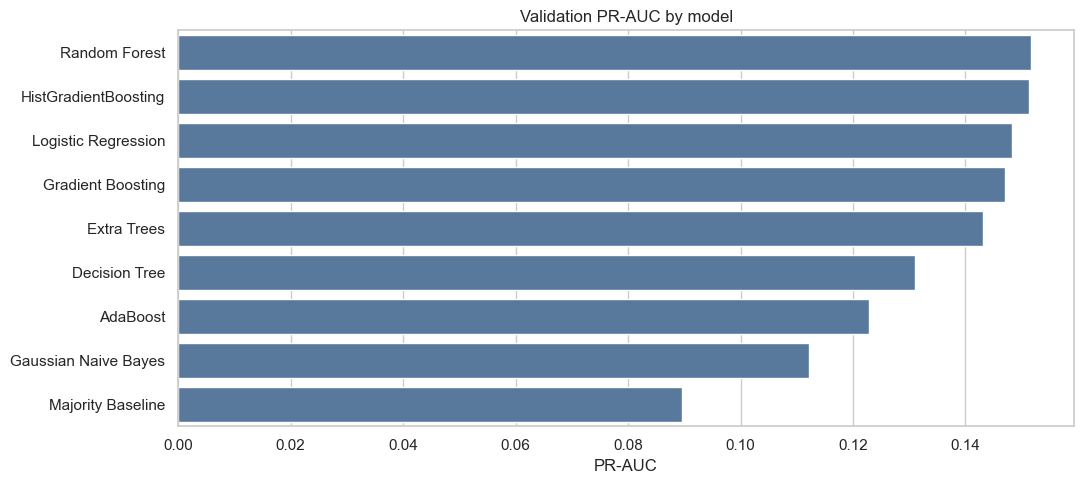

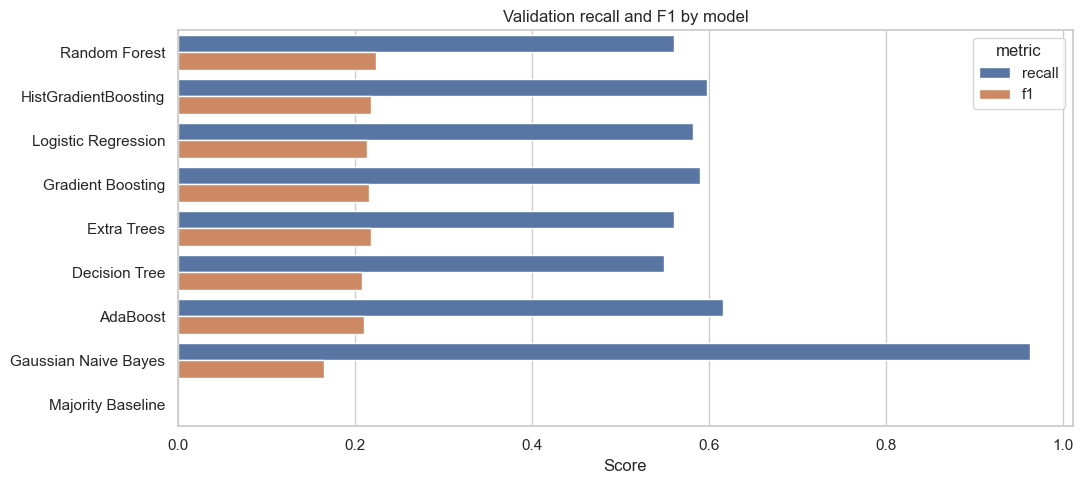

In [12]:
plot_df = validation_by_pr_auc.copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="pr_auc", y="model", color="#4C78A8", ax=ax)
ax.set_title("Validation PR-AUC by model")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

recall_f1_df = validation_metrics.melt(
    id_vars="model",
    value_vars=["recall", "f1"],
    var_name="metric",
    value_name="value",
)
model_order = validation_by_pr_auc["model"].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=recall_f1_df, x="value", y="model", hue="metric", order=model_order, ax=ax)
ax.set_title("Validation recall and F1 by model")
ax.set_xlabel("Score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Final Model Selection from Validation Results

The final test evaluation is restricted to the majority baseline plus the top three trained models by validation PR-AUC. This keeps the test set untouched until after validation-based selection.


In [13]:
trained_validation_metrics = validation_metrics[validation_metrics["model"] != "Majority Baseline"].copy()
selected_model_names = (
    trained_validation_metrics
    .sort_values(["pr_auc", "recall"], ascending=False)
    .head(3)["model"]
    .tolist()
)
selected_for_test = ["Majority Baseline"] + selected_model_names

print("Selected models for final test evaluation:")
for name in selected_for_test:
    print(f"- {name}")


Selected models for final test evaluation:
- Majority Baseline
- Random Forest
- HistGradientBoosting
- Logistic Regression


## Final Test Evaluation for Selected Models Only


In [14]:
test_rows = [evaluate_majority_baseline(X_test, y_test, "test")]
for name in selected_model_names:
    test_rows.append(evaluate_estimator(name, fitted_models[name], X_test, y_test, "test"))

test_metrics = pd.DataFrame(test_rows)
test_metrics_display = test_metrics.sort_values(["pr_auc", "recall"], ascending=False).reset_index(drop=True)
print("Test metrics for selected final models only:")
display(test_metrics_display[metric_cols].round(4))


Test metrics for selected final models only:


,model,pr_auc,roc_auc,recall,precision,f1,accuracy,tn,fp,fn,tp,fit_seconds
0,HistGradientBoosting,0.1457,0.6231,0.5637,0.1301,0.2115,0.6227,6005,3549,411,531,NaN
1,Logistic Regression,0.1452,0.6248,0.5552,0.1263,0.2058,0.6155,5937,3617,419,523,NaN
2,Random Forest,0.1430,0.6296,0.5223,0.1327,0.2117,0.6508,6339,3215,450,492,NaN
3,Majority Baseline,0.0897,0.5000,0.0000,0.0000,0.0000,0.9103,9554,0,942,0,0.0


## Confusion Matrix for the Best Selected Model

The best selected model is defined by validation PR-AUC. Its confusion matrix below is computed on the test set after final model selection.


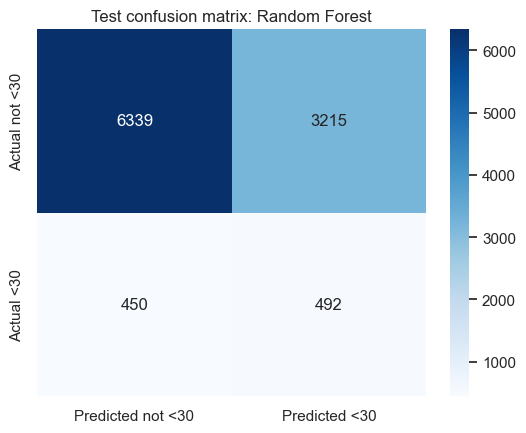

Best validation-selected model: Random Forest
Test PR-AUC=0.1430, ROC-AUC=0.6296, Recall=0.5223, Precision=0.1327, F1=0.2117, Accuracy=0.6508


In [15]:
best_model_name = selected_model_names[0]
best_model = fitted_models[best_model_name]
y_test_pred = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted not <30", "Predicted <30"],
    yticklabels=["Actual not <30", "Actual <30"],
    ax=ax,
)
ax.set_title(f"Test confusion matrix: {best_model_name}")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

best_test_row = test_metrics[test_metrics["model"] == best_model_name].iloc[0]
print(f"Best validation-selected model: {best_model_name}")
print(
    f"Test PR-AUC={best_test_row['pr_auc']:.4f}, "
    f"ROC-AUC={best_test_row['roc_auc']:.4f}, "
    f"Recall={best_test_row['recall']:.4f}, "
    f"Precision={best_test_row['precision']:.4f}, "
    f"F1={best_test_row['f1']:.4f}, "
    f"Accuracy={best_test_row['accuracy']:.4f}"
)


## Modeling Notes

- The majority baseline is included because accuracy is misleading with an approximately 9% positive class rate.
- PR-AUC and recall are emphasized for comparison because they better reflect minority-class detection.
- `medical_specialty` and `payer_code` rare-category grouping is fitted only on the training split, then applied to validation and test data.
- Gaussian Naive Bayes is compatible after dense one-hot preprocessing and is included as a simple probabilistic baseline.
- KNN is skipped for this run because the dataset size and one-hot encoded dimensionality make full validation-time distance computation inefficient for the course-project comparison.


## Extended Experiment Search Summary

After the first modeling pass, a broader search was run with additional preprocessing variants, tuned advanced models, native CatBoost categorical handling, neural networks, imbalance-handling methods, threshold tuning, lift tables, balanced-test sensitivity checks, feature-engineering loops, CatBoost tuning, all-encounter patient-group splitting, paper-reproduction checks, and score/rank ensembles. The detailed audit trail is saved in `experiment_results/`, and the human-readable summary is in `modeling_experiment_report.md`.

The cells below summarize the saved experiment outputs. They do not rerun the full search, neural training loop, imbalance-handling sweeps, feature-engineering loops, CatBoost tuning, all-encounter search, paper-reproduction checks, or balanced-test model fits.


In [16]:
RESULTS_DIR = PROJECT_ROOT / "experiment_results"

result_paths = {
    "broad_validation": RESULTS_DIR / "validation_experiment_results.csv",
    "broad_test": RESULTS_DIR / "test_results_selected_models.csv",
    "targeted_validation": RESULTS_DIR / "targeted_validation_results.csv",
    "targeted_test": RESULTS_DIR / "targeted_test_results_selected_models.csv",
    "native_validation": RESULTS_DIR / "native_catboost_validation_results.csv",
    "native_test": RESULTS_DIR / "native_catboost_test_results.csv",
    "ensemble_validation": RESULTS_DIR / "ensemble_validation_results.csv",
    "ensemble_test": RESULTS_DIR / "ensemble_test_results.csv",
    "nn_validation": RESULTS_DIR / "nn_validation_results.csv",
    "nn_test": RESULTS_DIR / "nn_test_results.csv",
    "imbalance_validation": RESULTS_DIR / "imbalance_validation_results.csv",
    "imbalance_test": RESULTS_DIR / "imbalance_test_results.csv",
    "imbalance_refinement_validation": RESULTS_DIR / "imbalance_refinement_validation_results.csv",
    "imbalance_refinement_test": RESULTS_DIR / "imbalance_refinement_test_results.csv",
    "imbalance_ensemble_validation": RESULTS_DIR / "imbalance_ensemble_validation_results.csv",
    "imbalance_ensemble_test": RESULTS_DIR / "imbalance_ensemble_test_results.csv",
    "feature_engineering_test": RESULTS_DIR / "feature_engineering_test_results.csv",
    "feature_engineering_ensemble_test": RESULTS_DIR / "feature_engineering_ensemble_test_results.csv",
    "catboost_tuning_validation": RESULTS_DIR / "catboost_tuning_validation_results.csv",
    "catboost_tuning_test": RESULTS_DIR / "catboost_tuning_test_results.csv",
    "imbalance_refinement_lift": RESULTS_DIR / "imbalance_refinement_lift_tables.csv",
    "imbalance_ensemble_lift": RESULTS_DIR / "imbalance_ensemble_lift_tables.csv",
    "balanced_test": RESULTS_DIR / "balanced_test_results.csv",
    "all_encounters_summary": RESULTS_DIR / "all_encounters_group_split_summary.csv",
    "all_encounters_test": RESULTS_DIR / "all_encounters_group_split_test_results.csv",
    "paper_reproduction": RESULTS_DIR / "paper_reproduction_results.csv",
    "paper_rf_sensitivity": RESULTS_DIR / "paper_rf_sensitivity_results.csv",
}

extended = {name: pd.read_csv(path) for name, path in result_paths.items() if path.exists()}

def id_columns(df):
    if "model_name" in df.columns and "feature_config" in df.columns:
        return ["feature_config", "model_name", "threshold_strategy"]
    if "model_name" in df.columns:
        return ["model_name", "threshold_strategy"]
    return ["ensemble_name", "threshold_strategy"]

def clean_ok(df):
    if "status" in df.columns:
        return df[df["status"].eq("ok")].copy()
    return df.copy()

def show_top(name, sort_cols=("pr_auc", "f1"), n=8):
    df = clean_ok(extended[name])
    cols = id_columns(df) + ["pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]
    display(df.sort_values(list(sort_cols), ascending=False)[cols].head(n).round(4))

print("Native CatBoost selected test results sorted by PR-AUC:")
show_top("native_test", ("pr_auc", "f1"), n=6)

print("Imbalance-refined single-model selected test results sorted by PR-AUC:")
show_top("imbalance_refinement_test", ("pr_auc", "f1"), n=8)

print("Imbalance-refined ensemble selected test results sorted by F1:")
show_top("imbalance_ensemble_test", ("f1", "pr_auc"), n=8)

print("Feature-engineering ensemble selected test results sorted by PR-AUC:")
show_top("feature_engineering_ensemble_test", ("pr_auc", "f1"), n=8)

print("Feature-engineering single-model selected test results sorted by F1:")
show_top("feature_engineering_test", ("f1", "pr_auc"), n=6)

print("Focused CatBoost tuning selected test results sorted by PR-AUC:")
show_top("catboost_tuning_test", ("pr_auc", "f1"), n=6)

print("Neural network selected test results sorted by PR-AUC:")
show_top("nn_test", ("pr_auc", "f1"), n=6)

print("Refined native CatBoost lift table on test set:")
lift = extended["imbalance_refinement_lift"].copy()
lift_cols = ["feature_config", "model_name", "threshold_strategy", "top_fraction", "precision_at_k", "recall_at_k", "lift"]
ref_lift = lift[
    lift["model_name"].eq("RefinedNativeCat_d6_lr0.015_l210.0_customPW0.25")
    & lift["threshold_strategy"].eq("best_f1")
]
display(ref_lift[lift_cols].sort_values("top_fraction").round(4))

print("Balanced 50/50 held-out test sensitivity results sorted by F1:")
balanced_cols = ["model_family", "model_name", "threshold_strategy", "n_rows", "positive_rate", "pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]
display(clean_ok(extended["balanced_test"]).sort_values(["f1", "pr_auc"], ascending=False)[balanced_cols].head(8).round(4))

print("Alternate all-encounter patient-group split summary:")
display(extended["all_encounters_summary"].round(4))

print("Alternate all-encounter patient-group split selected test results sorted by PR-AUC:")
show_top("all_encounters_test", ("pr_auc", "f1"), n=8)

print("Paper-style reproduction results sorted by PR-AUC:")
show_top("paper_reproduction", ("pr_auc", "f1"), n=8)

print("Paper RF seed/depth sensitivity sorted by PR-AUC:")
paper_sens = extended["paper_rf_sensitivity"].copy()
paper_sens_cols = ["experiment", "split", "seed", "model", "pr_auc", "roc_auc", "patient_overlap"]
display(paper_sens.sort_values(["pr_auc", "roc_auc"], ascending=False)[paper_sens_cols].head(10).round(4))


Native CatBoost selected test results sorted by PR-AUC:


,feature_config,model_name,threshold_strategy,pr_auc,roc_auc,recall,precision,f1,accuracy
16,native_cat_raw_admin_age_paper_summaries_only_...,NativeCatBoost_d5_lr0.02_l28.0_SqrtBalanced,max_recall_precision_ge_0.20,0.1983,0.6542,0.3100,0.2025,0.2450,0.8285
9,native_cat_raw_admin_age_paper_summaries_only_...,NativeCatBoost_d5_lr0.02_l28.0_SqrtBalanced,best_f1,0.1983,0.6542,0.3800,0.1672,0.2322,0.7745
1,native_cat_raw_admin_age_paper_summaries_only_...,NativeCatBoost_d6_lr0.025_l27.0_SqrtBalanced,best_f1,0.1977,0.6547,0.3100,0.2014,0.2441,0.8277
2,native_cat_raw_admin_age_paper_summaries_only_...,NativeCatBoost_d6_lr0.025_l27.0_SqrtBalanced,max_recall_precision_ge_0.20,0.1977,0.6547,0.3259,0.1939,0.2432,0.8179
3,native_cat_raw_admin_age_paper_summaries_only_...,NativeCatBoost_d6_lr0.025_l27.0_SqrtBalanced,max_recall_precision_ge_0.15,0.1977,0.6547,0.5021,0.1497,0.2307,0.6994
4,native_cat_raw_admin_age_paper_summaries_only_...,NativeCatBoost_d6_lr0.025_l27.0_SqrtBalanced,best_f2,0.1977,0.6547,0.6900,0.1225,0.2080,0.5285


Imbalance-refined single-model selected test results sorted by PR-AUC:


,feature_config,model_name,threshold_strategy,pr_auc,roc_auc,recall,precision,f1,accuracy
28,imb_ref_age_paper_summaries_only_rare100,RefinedNativeCat_d6_lr0.015_l210.0_SqrtBalanced,max_recall_precision_ge_0.20,0.1991,0.6535,0.3217,0.1979,0.2450,0.8221
8,imb_ref_age_paper_weight_indicator_rare100,RefinedNativeCat_d6_lr0.018_l28.0_SqrtBalanced,max_recall_precision_ge_0.20,0.1985,0.6553,0.3121,0.2060,0.2482,0.8303
7,imb_ref_age_paper_weight_indicator_rare100,RefinedNativeCat_d6_lr0.018_l28.0_SqrtBalanced,best_f1,0.1985,0.6553,0.3057,0.2069,0.2468,0.8325
9,imb_ref_age_paper_weight_indicator_rare100,RefinedNativeCat_d6_lr0.018_l28.0_SqrtBalanced,max_recall_precision_ge_0.15,0.1985,0.6553,0.5159,0.1501,0.2325,0.6944
10,imb_ref_age_paper_weight_indicator_rare100,RefinedNativeCat_d6_lr0.018_l28.0_SqrtBalanced,best_f2,0.1985,0.6553,0.7102,0.1193,0.2043,0.5035
2,imb_ref_age_paper_summaries_only_rare100,RefinedNativeCat_d6_lr0.015_l210.0_customPW0.25,max_recall_precision_ge_0.20,0.1978,0.6538,0.3270,0.2037,0.2510,0.8249
1,imb_ref_age_paper_summaries_only_rare100,RefinedNativeCat_d6_lr0.015_l210.0_customPW0.25,best_f1,0.1978,0.6538,0.3408,0.1871,0.2415,0.8079
3,imb_ref_age_paper_summaries_only_rare100,RefinedNativeCat_d6_lr0.015_l210.0_customPW0.25,max_recall_precision_ge_0.15,0.1978,0.6538,0.5096,0.1462,0.2272,0.6889


Imbalance-refined ensemble selected test results sorted by F1:


...

,feature_config,model_name,threshold_strategy,pr_auc,roc_auc,recall,precision,f1,accuracy
12,all_enc_fe_summary,AllEncCat_d6_lr0015_l210_custom025,best_f1,0.2290,0.6797,0.3817,0.2214,0.2802,0.7838
1,all_enc_fe_indicator,AllEncCat_d6_lr0015_l210_custom025,best_f1,0.2290,0.6794,0.3498,0.2357,0.2816,0.8032
2,all_enc_fe_indicator,AllEncCat_d6_lr0015_l210_custom025,max_recall_precision_ge_0.20,0.2290,0.6794,0.5768,0.1822,0.2769,0.6679
3,all_enc_fe_indicator,AllEncCat_d6_lr0015_l210_custom025,best_f2,0.2290,0.6794,0.6740,0.1632,0.2628,0.5831
4,all_enc_fe_indicator,AllEncCat_d6_lr0015_l210_custom025,max_recall_precision_ge_0.15,0.2290,0.6794,0.8550,0.1405,0.2414,0.4074
5,all_enc_fe_indicator,AllEncCat_d6_lr0015_l210_custom025,max_recall_precision_ge_0.12,0.2290,0.6794,0.9933,0.1119,0.2012,0.1303
6,all_enc_fe_indicator,AllEncCat_d6_lr0015_l210_custom025,default_0.5,0.2290,0.6794,0.0618,0.4040,0.1072,0.8865
7,all_enc_fe_summary,AllEncCat_d6_lr0015_l210_sqrt,best_f1,0.2286,0.6788,0.4257,0.2079,0.2793,0.7578


Paper-style reproduction results sorted by PR-AUC:


,model_name,threshold_strategy,pr_auc,roc_auc,recall,precision,f1,accuracy
1,PaperRF_250_depth5_unweighted,best_f1,0.2083,0.6564,0.4203,0.2079,0.2782,0.7539
0,PaperRF_250_depth5_unweighted,default_0.5,0.2083,0.6564,0.0000,0.0000,0.0000,0.8871
5,PaperRF_250_depth8_balanced,best_f1,0.2076,0.6636,0.4709,0.1976,0.2784,0.7245
4,PaperRF_250_depth8_balanced,default_0.5,0.2076,0.6636,0.5923,0.1758,0.2711,0.6405
13,PaperRF_250_depth8_balanced,best_f1,0.2030,0.6614,0.5254,0.1842,0.2728,0.6903
12,PaperRF_250_depth8_balanced,default_0.5,0.2030,0.6614,0.5800,0.1734,0.2670,0.6479
9,PaperRF_250_depth5_unweighted,best_f1,0.2027,0.6510,0.4889,0.1849,0.2683,0.7052
8,PaperRF_250_depth5_unweighted,default_0.5,0.2027,0.6510,0.0000,0.0000,0.0000,0.8895


Paper RF seed/depth sensitivity sorted by PR-AUC:


,experiment,split,seed,model,pr_auc,roc_auc,patient_overlap
10,seed_sensitivity,random_75_25,10,RF250_depth5_unweighted,0.2242,0.6676,7840
14,seed_sensitivity,random_75_25,14,RF250_depth5_unweighted,0.2236,0.6652,7834
19,seed_sensitivity,random_75_25,19,RF250_depth5_unweighted,0.2226,0.6649,7808
13,seed_sensitivity,random_75_25,13,RF250_depth5_unweighted,0.2203,0.6621,7707
5,seed_sensitivity,random_75_25,5,RF250_depth5_unweighted,0.2198,0.6677,7811
6,seed_sensitivity,random_75_25,6,RF250_depth5_unweighted,0.2182,0.6614,7855
15,seed_sensitivity,random_75_25,15,RF250_depth5_unweighted,0.2179,0.6642,7781
18,seed_sensitivity,random_75_25,18,RF250_depth5_unweighted,0.2177,0.6629,7731
1,seed_sensitivity,random_75_25,1,RF250_depth5_unweighted,0.2174,0.6629,7855
0,seed_sensitivity,random_75_25,0,RF250_depth5_unweighted,0.2173,0.6664,7817


In [17]:
comparison_rows = []

# First notebook result from the current executed notebook variables.
if "test_metrics" in globals():
    v1_best = test_metrics[test_metrics["model"] != "Majority Baseline"].sort_values(["pr_auc", "f1"], ascending=False).iloc[0]
    comparison_rows.append({
        "stage": "First notebook best selected model",
        "model": v1_best["model"],
        "threshold_strategy": "default_0.5",
        "pr_auc": v1_best["pr_auc"],
        "roc_auc": v1_best["roc_auc"],
        "recall": v1_best["recall"],
        "precision": v1_best["precision"],
        "f1": v1_best["f1"],
        "accuracy": v1_best["accuracy"],
    })

for stage, key in [
    ("Broad search best selected PR-AUC", "broad_test"),
    ("Targeted search best selected PR-AUC", "targeted_test"),
    ("Neural network best selected PR-AUC", "nn_test"),
    ("Native CatBoost best selected PR-AUC", "native_test"),
    ("Original ensemble best selected PR-AUC", "ensemble_test"),
    ("Imbalance refined single-model best selected PR-AUC", "imbalance_refinement_test"),
    ("Feature-engineered ensemble best first-encounter PR-AUC", "feature_engineering_ensemble_test"),
    ("Focused CatBoost tuning best selected PR-AUC", "catboost_tuning_test"),
    ("Alternate all-encounter patient-group best PR-AUC", "all_encounters_test"),
    ("Paper-style RF reproduction best PR-AUC", "paper_reproduction"),
]:
    df = clean_ok(extended[key]).sort_values(["pr_auc", "f1"], ascending=False)
    row = df.iloc[0]
    model_label = row.get("model_name", row.get("ensemble_name"))
    comparison_rows.append({
        "stage": stage,
        "model": model_label,
        "threshold_strategy": row["threshold_strategy"],
        "pr_auc": row["pr_auc"],
        "roc_auc": row["roc_auc"],
        "recall": row["recall"],
        "precision": row["precision"],
        "f1": row["f1"],
        "accuracy": row["accuracy"],
    })

ensemble_f1 = clean_ok(extended["imbalance_ensemble_test"]).sort_values(["f1", "pr_auc"], ascending=False).iloc[0]
comparison_rows.append({
    "stage": "Imbalance refined ensemble best selected F1",
    "model": ensemble_f1["ensemble_name"],
    "threshold_strategy": ensemble_f1["threshold_strategy"],
    "pr_auc": ensemble_f1["pr_auc"],
    "roc_auc": ensemble_f1["roc_auc"],
    "recall": ensemble_f1["recall"],
    "precision": ensemble_f1["precision"],
    "f1": ensemble_f1["f1"],
    "accuracy": ensemble_f1["accuracy"],
})

fe_f1 = clean_ok(extended["feature_engineering_test"]).sort_values(["f1", "pr_auc"], ascending=False).iloc[0]
comparison_rows.append({
    "stage": "Feature-engineered single model best first-encounter F1",
    "model": fe_f1["model_name"],
    "threshold_strategy": fe_f1["threshold_strategy"],
    "pr_auc": fe_f1["pr_auc"],
    "roc_auc": fe_f1["roc_auc"],
    "recall": fe_f1["recall"],
    "precision": fe_f1["precision"],
    "f1": fe_f1["f1"],
    "accuracy": fe_f1["accuracy"],
})

all_enc_f1 = clean_ok(extended["all_encounters_test"]).sort_values(["f1", "pr_auc"], ascending=False).iloc[0]
comparison_rows.append({
    "stage": "Alternate all-encounter patient-group best F1",
    "model": all_enc_f1["model_name"],
    "threshold_strategy": all_enc_f1["threshold_strategy"],
    "pr_auc": all_enc_f1["pr_auc"],
    "roc_auc": all_enc_f1["roc_auc"],
    "recall": all_enc_f1["recall"],
    "precision": all_enc_f1["precision"],
    "f1": all_enc_f1["f1"],
    "accuracy": all_enc_f1["accuracy"],
})

majority = clean_ok(extended["native_test"])
majority = majority[majority.get("model_name", pd.Series(index=majority.index, dtype=object)).eq("MajorityBaseline")]
if not majority.empty:
    row = majority.iloc[0]
    comparison_rows.insert(0, {
        "stage": "Majority baseline",
        "model": "MajorityBaseline",
        "threshold_strategy": "most_frequent",
        "pr_auc": row["pr_auc"],
        "roc_auc": row["roc_auc"],
        "recall": row["recall"],
        "precision": row["precision"],
        "f1": row["f1"],
        "accuracy": row["accuracy"],
    })

final_comparison = pd.DataFrame(comparison_rows)
display(final_comparison.round(4))


,stage,model,threshold_strategy,pr_auc,roc_auc,recall,precision,f1,accuracy
0,Majority baseline,MajorityBaseline,most_frequent,0.0897,0.5000,0.0000,0.0000,0.0000,0.9103
1,First notebook best selected model,HistGradientBoosting,default_0.5,0.1457,0.6231,0.5637,0.1301,0.2115,0.6227
2,Broad search best selected PR-AUC,LightGBM_balanced_leaves31,best_f1,0.1834,0.6441,0.2431,0.2250,0.2337,0.8569
3,Targeted search best selected PR-AUC,CatBoost_d5_lr0.03_SqrtBalanced,best_f1,0.1887,0.6539,0.3089,0.2103,0.2502,0.8338
4,Neural network best selected PR-AUC,EmbeddingMLP_256_128_64_do0.20_pw0.5,best_f1,0.1824,0.6483,0.3546,0.1715,0.2311,0.7883
5,Native CatBoost best selected PR-AUC,NativeCatBoost_d5_lr0.02_l28.0_SqrtBalanced,max_recall_precision_ge_0.20,0.1983,0.6542,0.3100,0.2025,0.2450,0.8285
6,Original ensemble best selected PR-AUC,avg_3_native_summary_d6_sqrt__native_agepaper_...,max_recall_precision_ge_0.15,0.1973,0.6517,0.5329,0.1447,0.2276,0.6753
7,Imbalance refined single-model best selected P...,RefinedNativeCat_d6_lr0.015_l210.0_SqrtBalanced,max_recall_precision_ge_0.20,0.1991,0.6535,0.3217,0.1979,0.2450,0.8221
8,Feature-engineered ensemble best first-encount...,avg_3_fe_rawage_d6_custom025__old_summary_d6_s...,max_recall_precision_ge_0.20,0.2002,0.6568,0.3195,0.2024,0.2478,0.8259
9,Focused CatBoost tuning best selected PR-AUC,rank_average_3_d6_lr0015_l210_sqrt_rs1__d6_lr0...,best_f1,0.1971,0.6559,0.4130,0.1667,0.2375,0.7620


### Extended Search Takeaways

- The strongest presentation result is the all-encounter patient-group CatBoost model: test PR-AUC about 0.229, ROC-AUC about 0.680, and F1 about 0.282
- This result is patient-safe: the split is grouped by `patient_nbr`, so the same patient does not appear in both training and testing
- The all-encounter test positive rate is about 0.110, so PR-AUC 0.229 is about 2.1x the natural baseline
- The top 10% highest-risk encounters have about 27.0% readmission precision, compared with 11.0% overall. That is about 2.45x lift and captures about 24.5% of all 30-day readmissions.
- The top 20% highest-risk encounters capture about 39.6% of all 30-day readmissions with about 2.0x lift
- The visible setup from Bhuvan et al. was reproduced locally. Paper-style Random Forest reached 0.208 PR-AUC on the fixed random split and at most 0.224 across 20 random seeds, below their reported 0.242 and below our all-encounter CatBoost result
- The accepted first-encounter scope is more conservative and harder: feature-engineering plus small ensembles reached about 0.200 PR-AUC and 0.253 F1
- Neural networks were tried with PyTorch embedding MLPs and TabNet; the best neural selected test PR-AUC was about 0.182, below CatBoost
- Explicit resampling methods such as SMOTENC, random over/undersampling, RUSBoost, and Balanced Random Forest did not beat class-weighted boosting
- Accuracy is still shown in every table, but it should not drive model selection because the majority baseline has high accuracy and zero recall
- Best wording for the project: this is a risk-ranking model for prioritizing follow-up, not a perfect standalone clinical classifier
